# code to combine ITS_LIVE velocities with CautoRIFT velocities and calculate weighted monthly average velocities

## import libraries

In [1]:
import numpy as np
import pandas as pd
import os
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates
import itslive
from dateutil.relativedelta import relativedelta
import matplotlib.dates as mdates

/Users/lindsaysummers/micromamba/envs/compare_itslive_cautorift/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## modify inputs

In [2]:
#inputs - WOLVERINE

#path to csv with lon/lat points along centerline
points_path = '/Users/lindsaysummers/Documents/Research/Velocity/Wolverine/RGI_data/'
points_name = 'centerline_points_latlon_0.5km_spacing.csv'

#date_dt preference (integer)
date_dt_min = 20
date_dt_max = 40

#start date and end date for velocities (string)
start = '2015-01-01'
end = '2025-01-01'

#path to extracted CautoRIFT velocities
cautorift_path = '/Users/lindsaysummers/Documents/Research/Cautorift/Results_240m/Extracted/Wolverine/'
cautorift_filename = 'wolverine_cautorift_velocities_xplatform.csv'

#path and filename for outputs
out_path = '/Users/lindsaysummers/Documents/Research/Velocity/Wolverine/itslive+cautorift/'
out_name = 'weighted_monthly_avg_velocity_df'

## import lon/lat points

In [3]:
#import csv containing lat lon points
points_list = pd.read_csv(os.path.join(points_path, points_name))
points_list = points_list.values.tolist()

#dictionary to store points
points = {}

for pt in range(len(points_list)):
    points[pt+1] = points_list[pt]
    print(f'point {pt+1} added to points directory')

point 1 added to points directory
point 2 added to points directory
point 3 added to points directory
point 4 added to points directory
point 5 added to points directory
point 6 added to points directory
point 7 added to points directory
point 8 added to points directory
point 9 added to points directory
point 10 added to points directory
point 11 added to points directory
point 12 added to points directory
point 13 added to points directory
point 14 added to points directory


## get ITS_LIVE velocities

In [4]:
#read in data at each point from itslive
#create a dataframe with time and velocity and date_dt for each point

#dictionary to store velocities
velocity_dataframes = {}

for i in range(len(points_list)):
  pt = points_list[i]
  timeseries_datasets = itslive.velocity_cubes.get_time_series([pt])
  velocity = timeseries_datasets[0]['time_series']['v']
  mid_date = timeseries_datasets[0]['time_series']['mid_date']
  mid_date = pd.to_datetime(mid_date)
  date_dt = timeseries_datasets[0]['time_series']['date_dt']
  date_dt = pd.to_timedelta(date_dt)

  #calculate start_date and end_date based on mid_date and date_dt
  begin_date = mid_date - (date_dt/2)
  stop_date = mid_date + (date_dt/2)
  begin_date = pd.to_datetime(start)
  stop_date = pd.to_datetime(end)

  v = pd.DataFrame({'start_date':begin_date, 'end_date': stop_date, 'mid_date':mid_date, 'date_dt':date_dt, 'velocity (m/yr)':velocity})
  velocity_dataframes[f'pt{i+1}'] = v
#  itslive = velocity_dataframes
  print(f'Created dataframe for pt{i+1} ITS_LIVE velocities')

/Users/lindsaysummers/micromamba/envs/compare_itslive_cautorift/lib/python3.13/site-packages/itslive/velocity_cubes/_cubes.py:224: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  xr_da = xr.open_dataset(


Created dataframe for pt1 ITS_LIVE velocities
Created dataframe for pt2 ITS_LIVE velocities
Created dataframe for pt3 ITS_LIVE velocities
Created dataframe for pt4 ITS_LIVE velocities
Created dataframe for pt5 ITS_LIVE velocities
Created dataframe for pt6 ITS_LIVE velocities
Created dataframe for pt7 ITS_LIVE velocities
Created dataframe for pt8 ITS_LIVE velocities
Created dataframe for pt9 ITS_LIVE velocities
Created dataframe for pt10 ITS_LIVE velocities
Created dataframe for pt11 ITS_LIVE velocities
Created dataframe for pt12 ITS_LIVE velocities
Created dataframe for pt13 ITS_LIVE velocities
Created dataframe for pt14 ITS_LIVE velocities


## filter date_dt for ITS_LIVE

In [5]:
#get rid of rows with date_dt not within desired range
for pt in velocity_dataframes.keys():
  velocity_dataframes[f'pt{i}'] = velocity_dataframes[f'pt{i}'].sort_values(by='mid_date')
  velocity_dataframes[f'pt{i}'] = velocity_dataframes[f'pt{i}'][velocity_dataframes[f'pt{i}']['date_dt'] >= pd.Timedelta(days=date_dt_min)]
  velocity_dataframes[f'pt{i}'] = velocity_dataframes[f'pt{i}'][velocity_dataframes[f'pt{i}']['date_dt'] <= pd.Timedelta(days=date_dt_max)]
  velocity_dataframes[f'pt{i}'] = velocity_dataframes[f'pt{i}'].reset_index(drop=True)
  print(f'Filtered date_dt for pt{pt}')

Filtered date_dt for ptpt1
Filtered date_dt for ptpt2
Filtered date_dt for ptpt3
Filtered date_dt for ptpt4
Filtered date_dt for ptpt5
Filtered date_dt for ptpt6
Filtered date_dt for ptpt7
Filtered date_dt for ptpt8
Filtered date_dt for ptpt9
Filtered date_dt for ptpt10
Filtered date_dt for ptpt11
Filtered date_dt for ptpt12
Filtered date_dt for ptpt13
Filtered date_dt for ptpt14


## import CautoRIFT velocities

In [6]:
#import cautorift
cautorift_data = pd.read_csv(f'{cautorift_path}{cautorift_filename}')

#dictionary to store cautorift velocities
cautorift = {}
for i, point in points.items():
  #extract column for current point
  cautorift[f'pt{i}'] = pd.DataFrame()
  cautorift[f'pt{i}']['mid_date'] = pd.to_datetime(cautorift_data['mid_date'])
  cautorift[f'pt{i}']['date_dt'] = pd.to_timedelta(cautorift_data['date_dt'], unit='D') #convert date_dt to timedelta
  cautorift[f'pt{i}']['velocity'] = cautorift_data[f'pt{i}'] #column names = pt1, pt2, etc.

  #calculate start_date and end_date based on mid_date and date_dt
  start_date = cautorift[f'pt{i}']['mid_date'] - (cautorift[f'pt{i}']['date_dt']/2)
  end_date = cautorift[f'pt{i}']['mid_date'] + (cautorift[f'pt{i}']['date_dt']/2)
  cautorift[f'pt{i}']['start_date'] = start_date
  cautorift[f'pt{i}']['end_date'] = end_date

  print(f'Created dataframe for pt{i} CautoRIFT velocities')

Created dataframe for pt1 CautoRIFT velocities
Created dataframe for pt2 CautoRIFT velocities
Created dataframe for pt3 CautoRIFT velocities
Created dataframe for pt4 CautoRIFT velocities
Created dataframe for pt5 CautoRIFT velocities
Created dataframe for pt6 CautoRIFT velocities
Created dataframe for pt7 CautoRIFT velocities
Created dataframe for pt8 CautoRIFT velocities
Created dataframe for pt9 CautoRIFT velocities
Created dataframe for pt10 CautoRIFT velocities
Created dataframe for pt11 CautoRIFT velocities
Created dataframe for pt12 CautoRIFT velocities
Created dataframe for pt13 CautoRIFT velocities
Created dataframe for pt14 CautoRIFT velocities


## filter date_dt for CautoRIFT

In [7]:
#filter for date_dt
for i, point in points.items():
  cautorift[f'pt{i}'] = cautorift[f'pt{i}'].sort_values(by='mid_date')
  cautorift[f'pt{i}'] = cautorift[f'pt{i}'][(cautorift[f'pt{i}']['date_dt'] >= pd.Timedelta(days=date_dt_min)) & (cautorift[f'pt{i}']['date_dt'] <= pd.Timedelta(days=date_dt_max))].copy()
  cautorift[f'pt{i}'] = cautorift[f'pt{i}'].reset_index(drop=True)
  print(f'Filtered date_dt for pt{i}')

Filtered date_dt for pt1
Filtered date_dt for pt2
Filtered date_dt for pt3
Filtered date_dt for pt4
Filtered date_dt for pt5
Filtered date_dt for pt6
Filtered date_dt for pt7
Filtered date_dt for pt8
Filtered date_dt for pt9
Filtered date_dt for pt10
Filtered date_dt for pt11
Filtered date_dt for pt12
Filtered date_dt for pt13
Filtered date_dt for pt14


## combine ITS_LIVE and CautoRIFT for each point

In [8]:
#combine cautorift and itslive dfs for each point
combined_velocity_dfs = {}
for i, point in points.items():
  combined_velocity_dfs[f'pt{i}'] = pd.merge(velocity_dataframes[f'pt{i}'], cautorift[f'pt{i}'], on='mid_date', how='outer')
  combined_velocity_dfs[f'pt{i}'] = combined_velocity_dfs[f'pt{i}'].sort_values(by='mid_date')
  combined_velocity_dfs[f'pt{i}'] = combined_velocity_dfs[f'pt{i}'].reset_index(drop=True)
  print(f'Combined dataframe for pt{i}')

Combined dataframe for pt1
Combined dataframe for pt2
Combined dataframe for pt3
Combined dataframe for pt4
Combined dataframe for pt5
Combined dataframe for pt6
Combined dataframe for pt7
Combined dataframe for pt8
Combined dataframe for pt9
Combined dataframe for pt10
Combined dataframe for pt11
Combined dataframe for pt12
Combined dataframe for pt13
Combined dataframe for pt14


In [9]:
global_start_date = pd.to_datetime(start)
global_end_date = pd.to_datetime(end)

point_dataframes = {}
for i, point in points.items():
    #df for the current point from the combined_velocity_dfs dictionary
    point_dataframes[f'pt{i}_df'] = combined_velocity_dfs[f'pt{i}'][['mid_date', 'velocity (m/yr)', 'velocity']].copy()

    #combine velocity columns, prioritizing ITS_LIVE if both exist
    point_dataframes[f'pt{i}_df']['velocity'] = point_dataframes[f'pt{i}_df']['velocity (m/yr)'].combine_first(point_dataframes[f'pt{i}_df']['velocity'])

    #only keep mid_date and combined velocity column
    point_dataframes[f'pt{i}_df'] = point_dataframes[f'pt{i}_df'][['mid_date', 'velocity']]

    #make sure mid_date column is in datetime format
    point_dataframes[f'pt{i}_df']['mid_date'] = pd.to_datetime(point_dataframes[f'pt{i}_df']['mid_date'])

    #filter so mid_date is between bounds
    point_dataframes[f'pt{i}_df'] = point_dataframes[f'pt{i}_df'][
    (point_dataframes[f'pt{i}_df']['mid_date'] >= global_start_date) &
    (point_dataframes[f'pt{i}_df']['mid_date'] <= global_end_date)
]

## plot combined velocity data

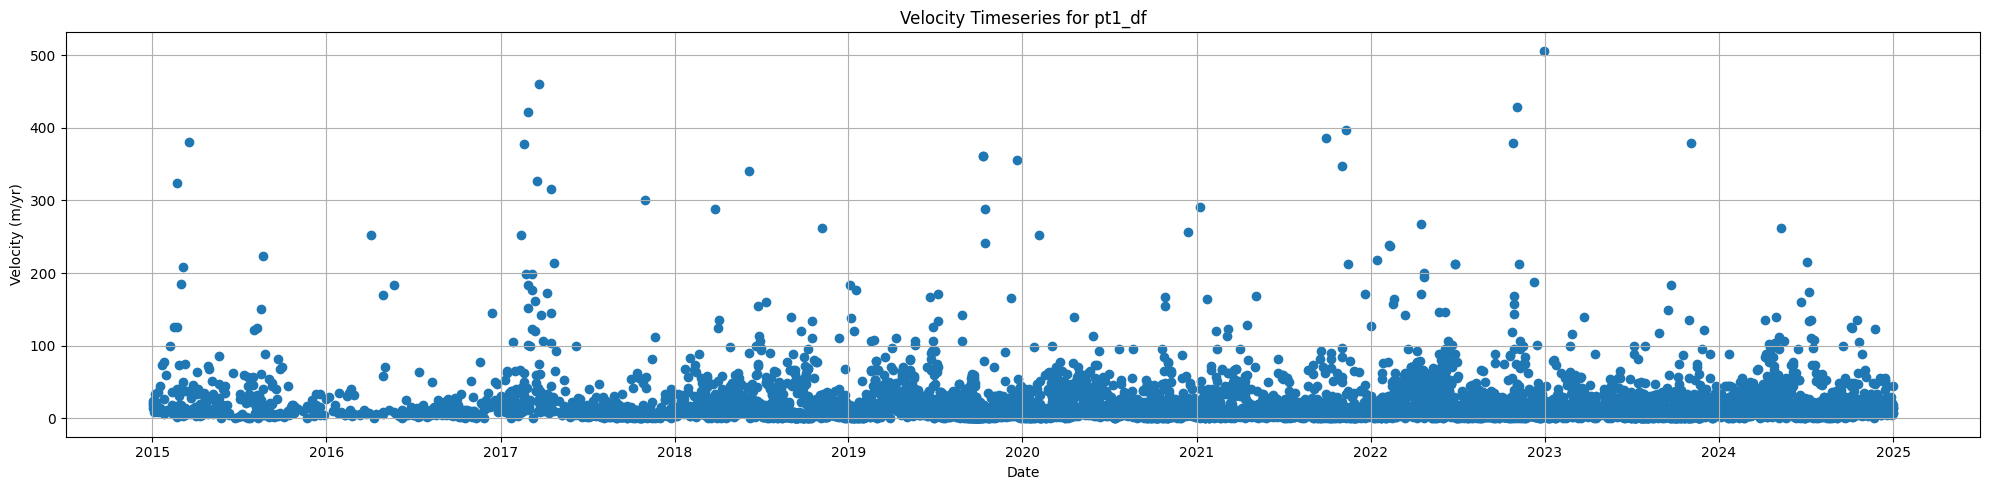

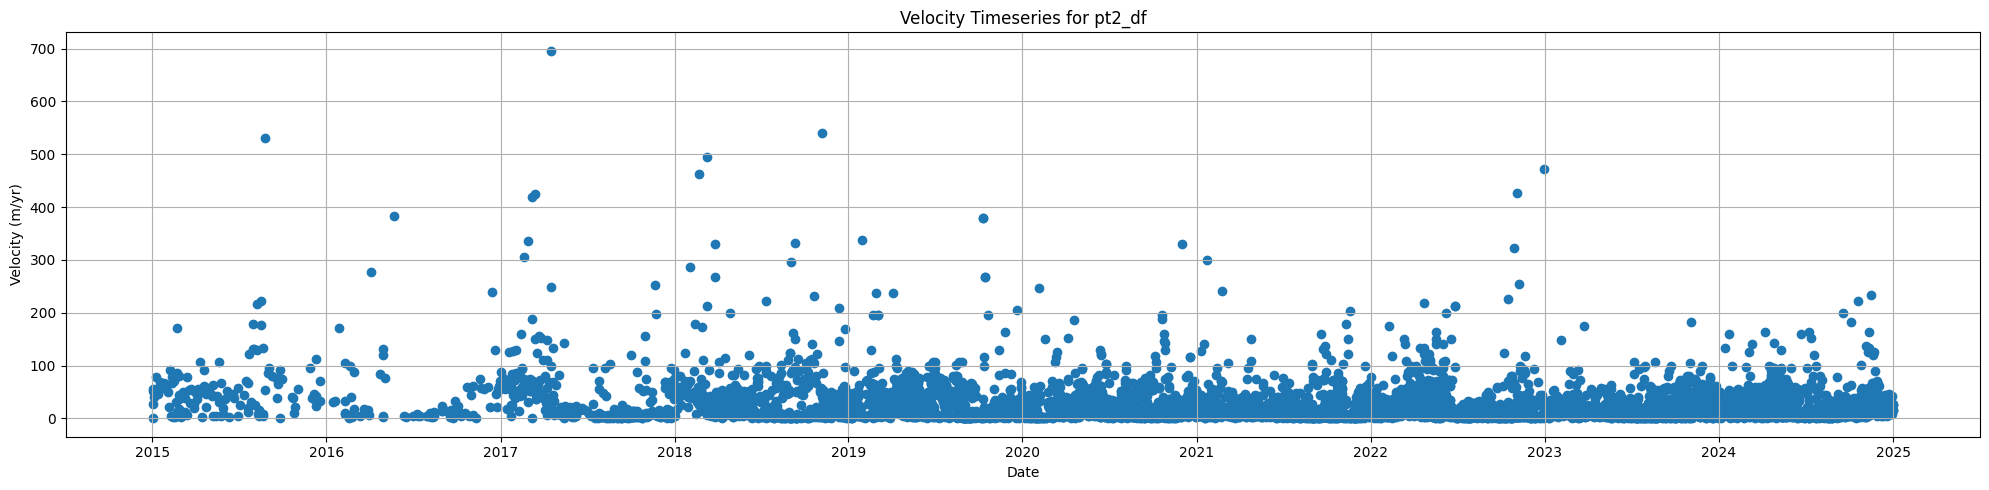

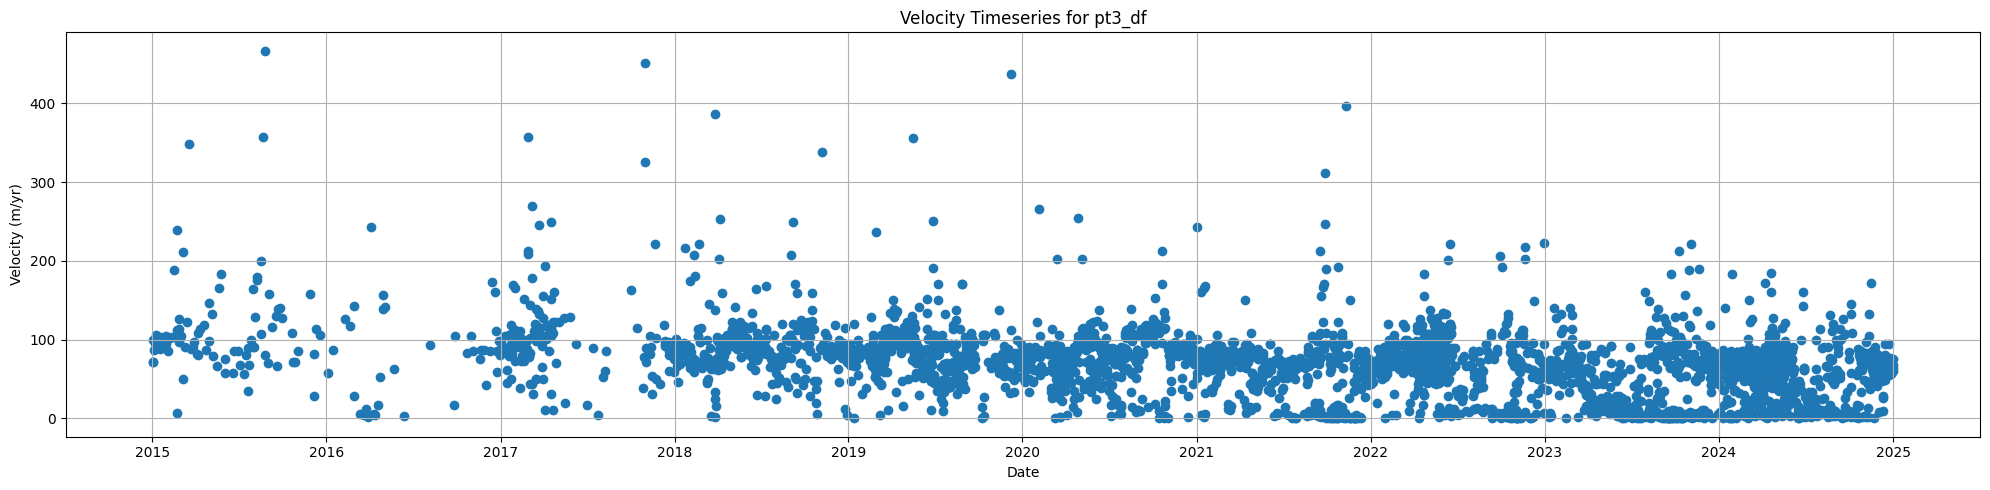

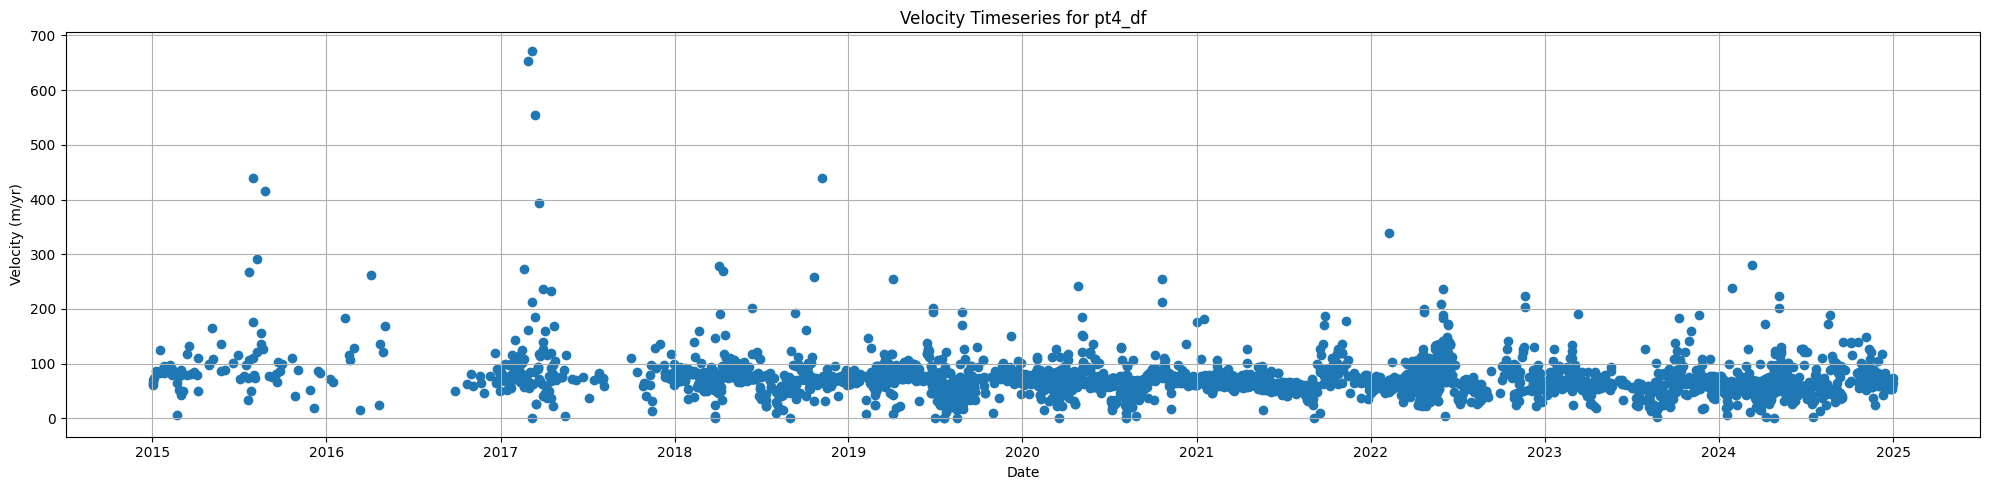

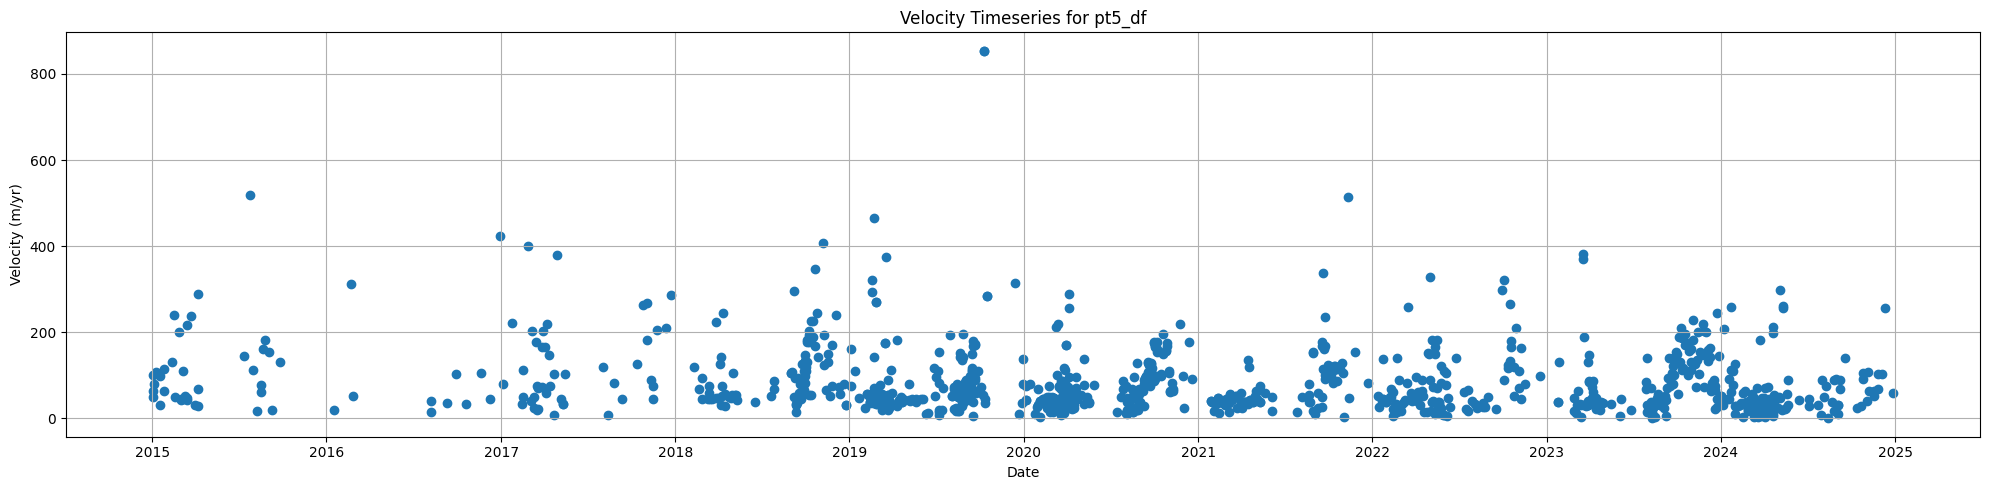

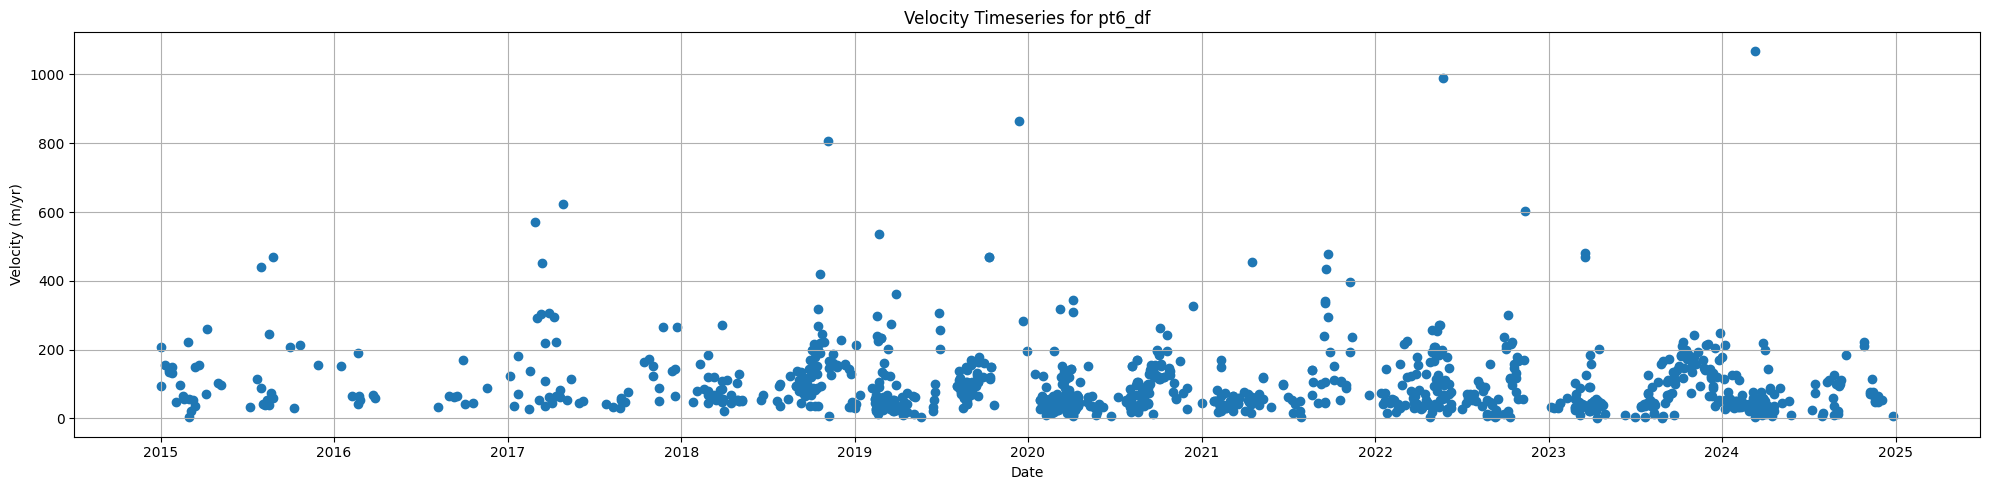

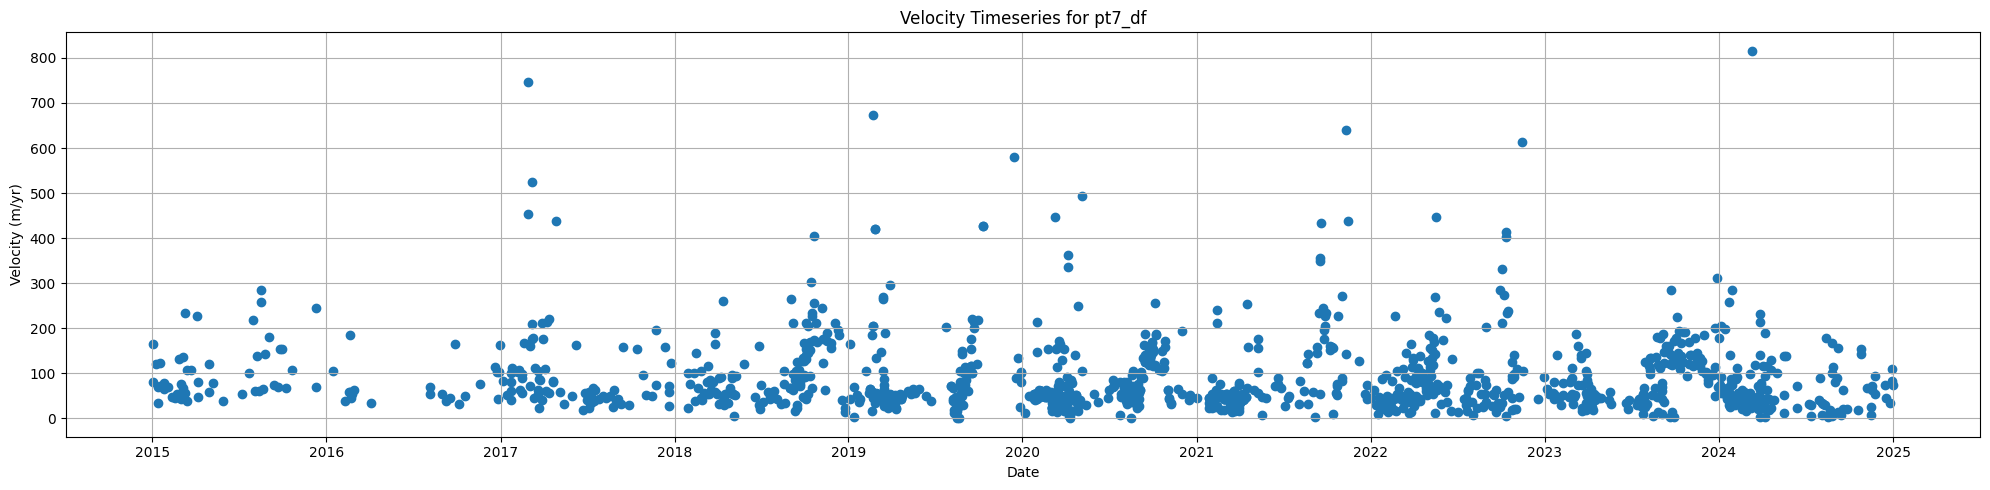

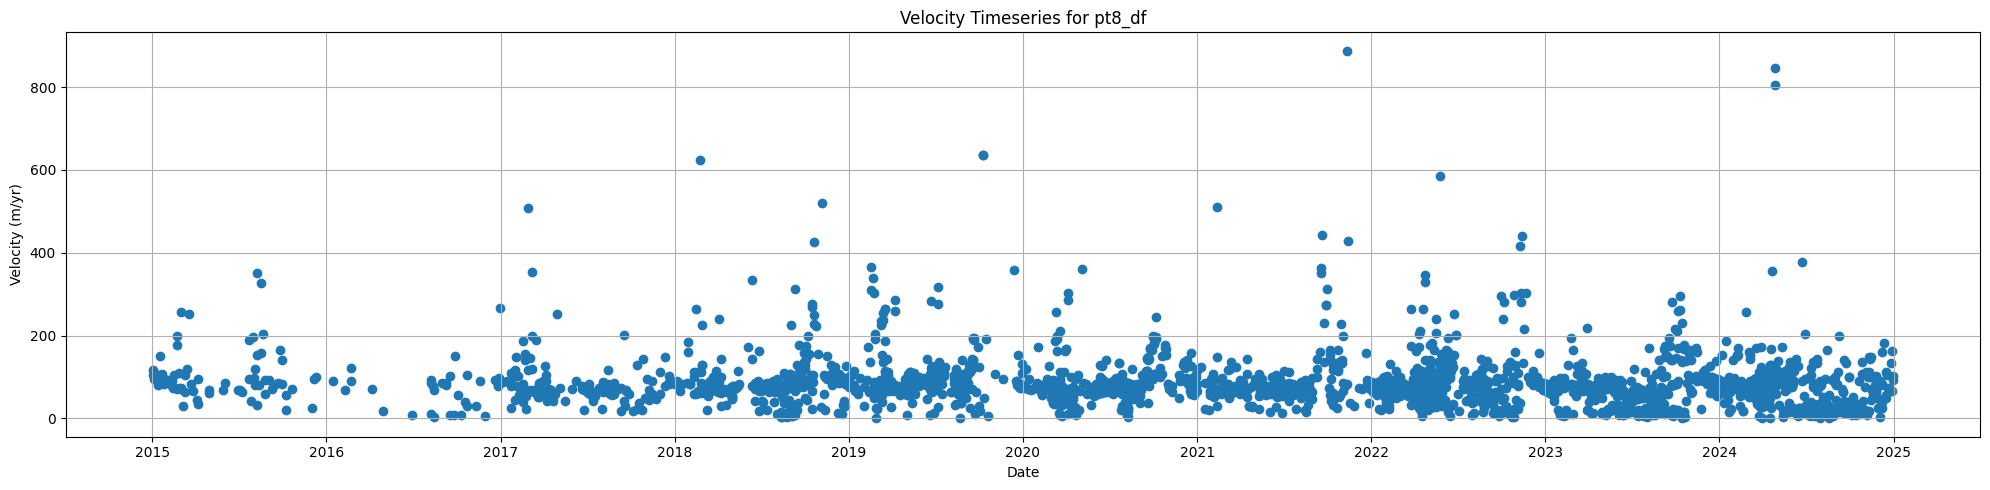

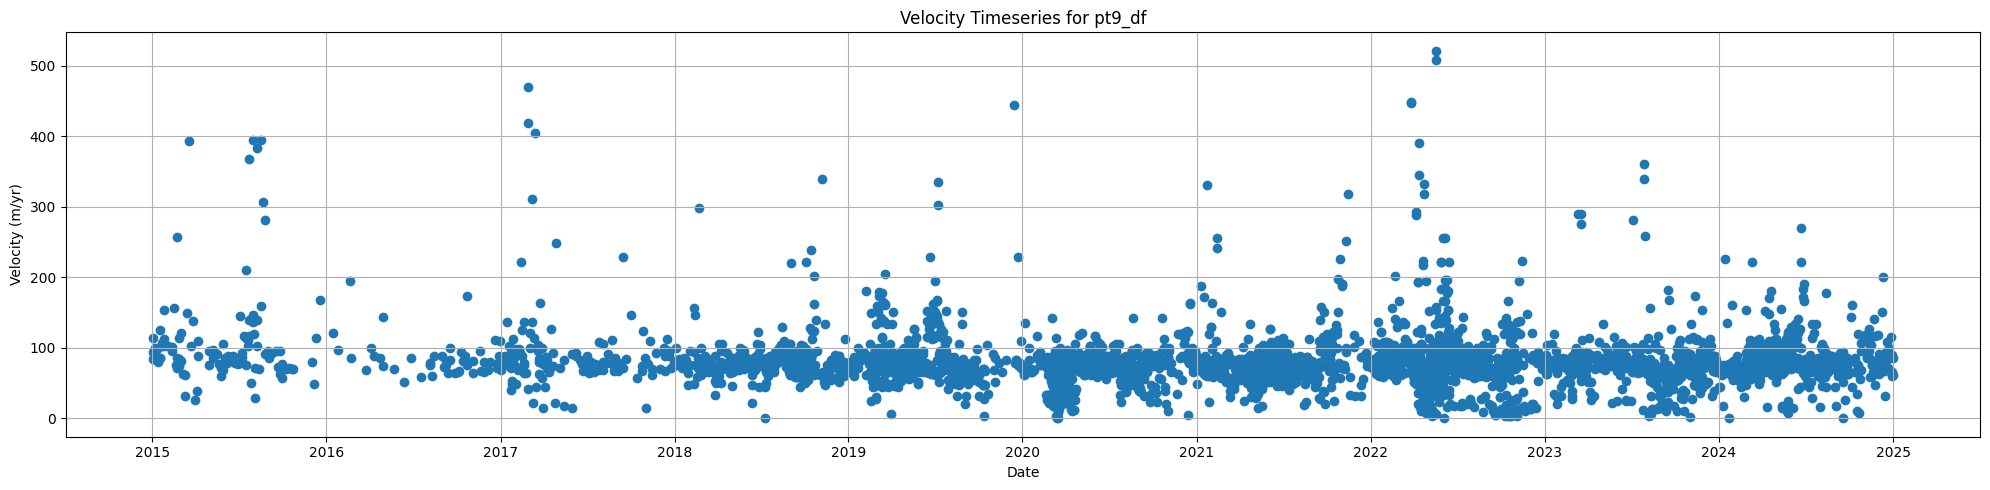

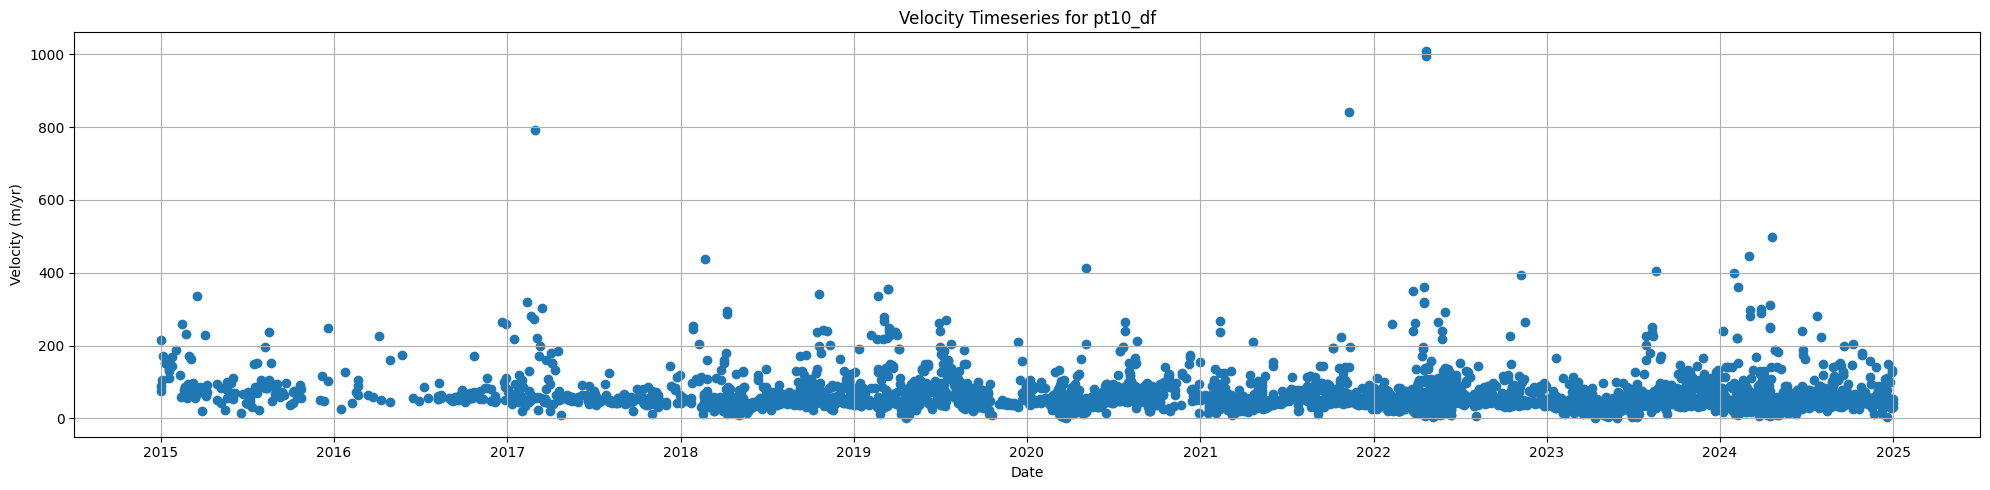

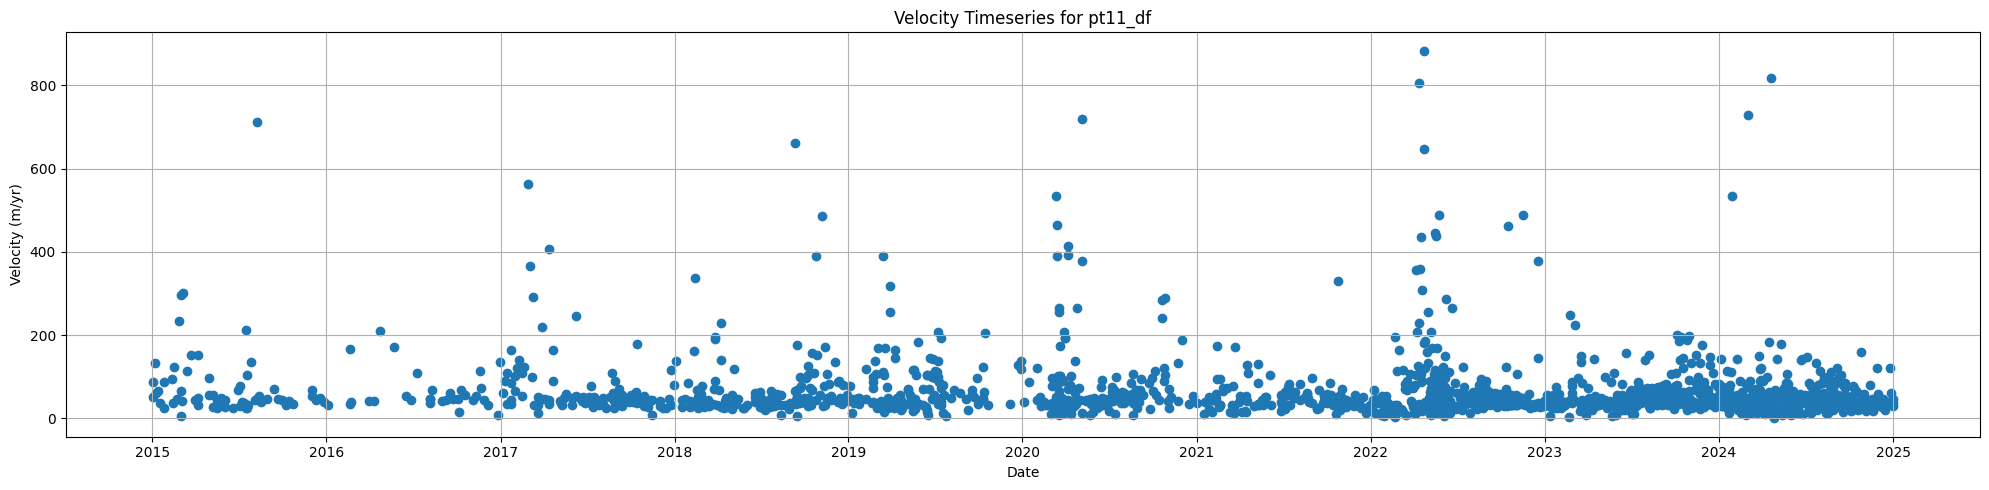

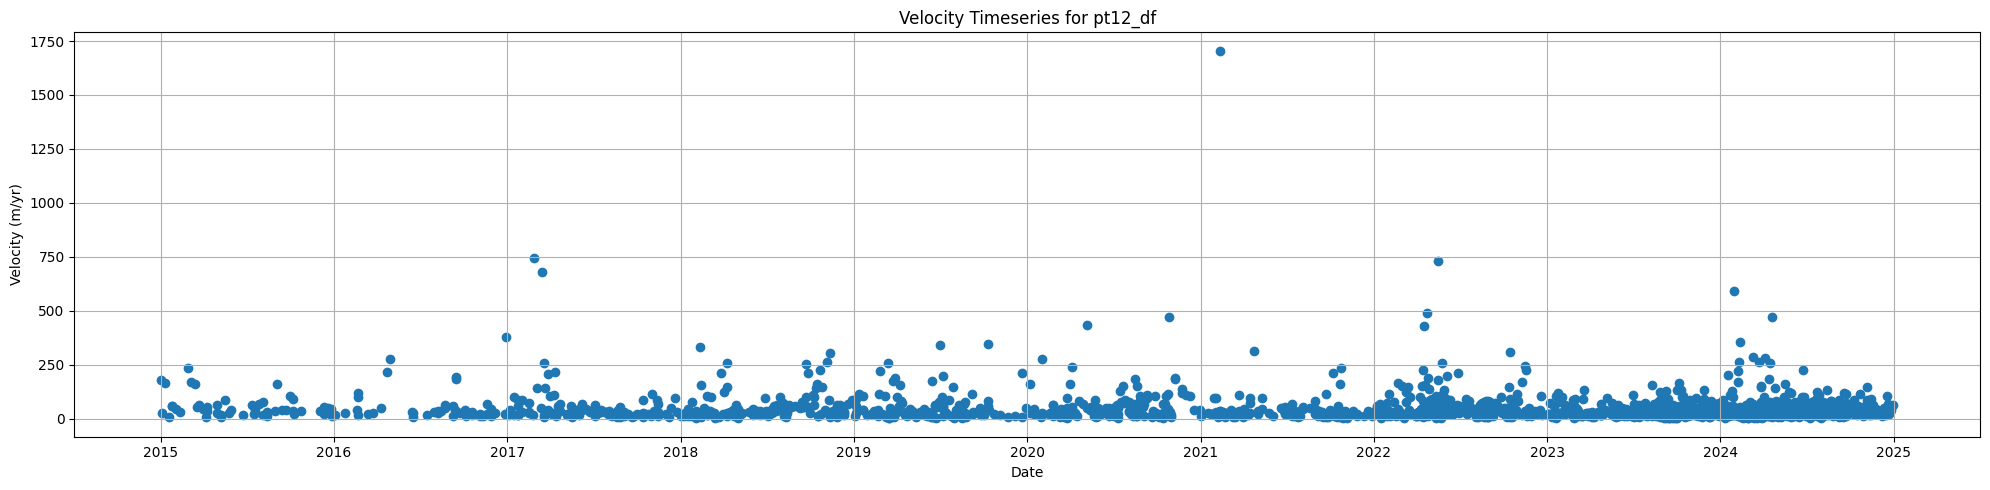

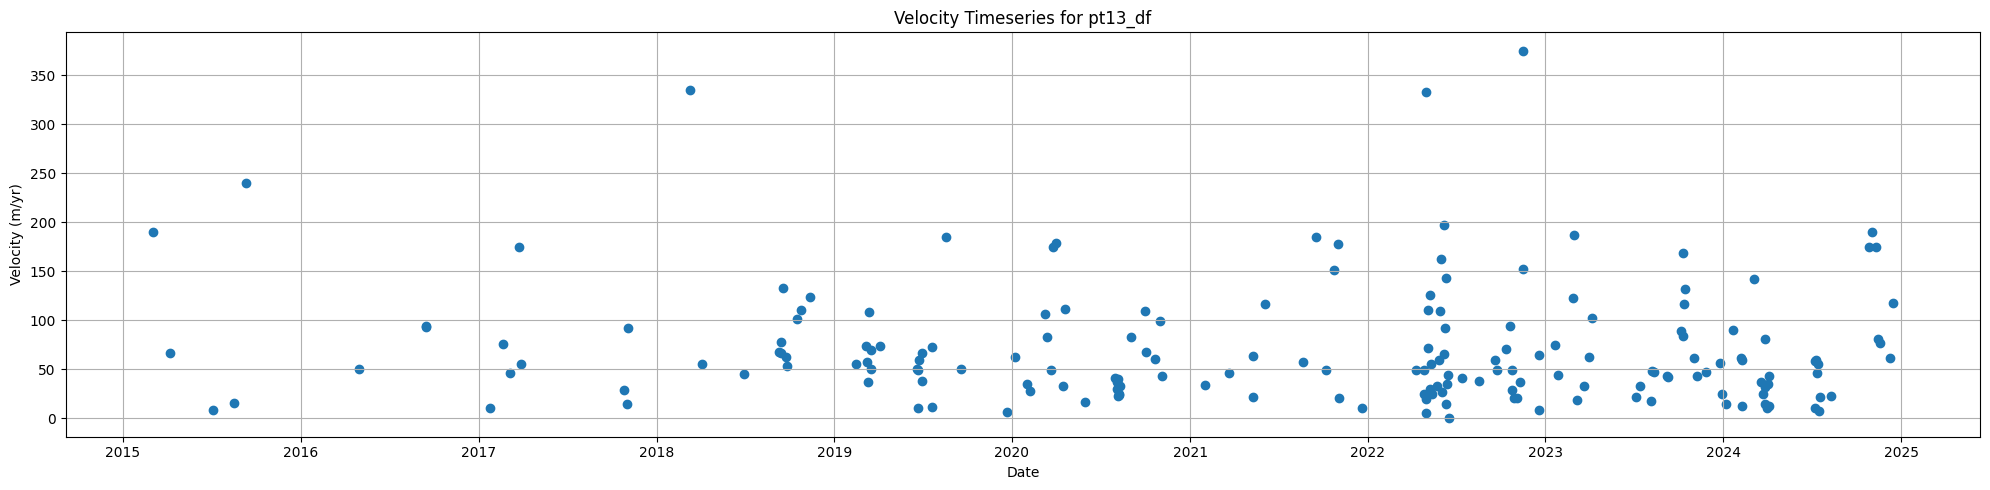

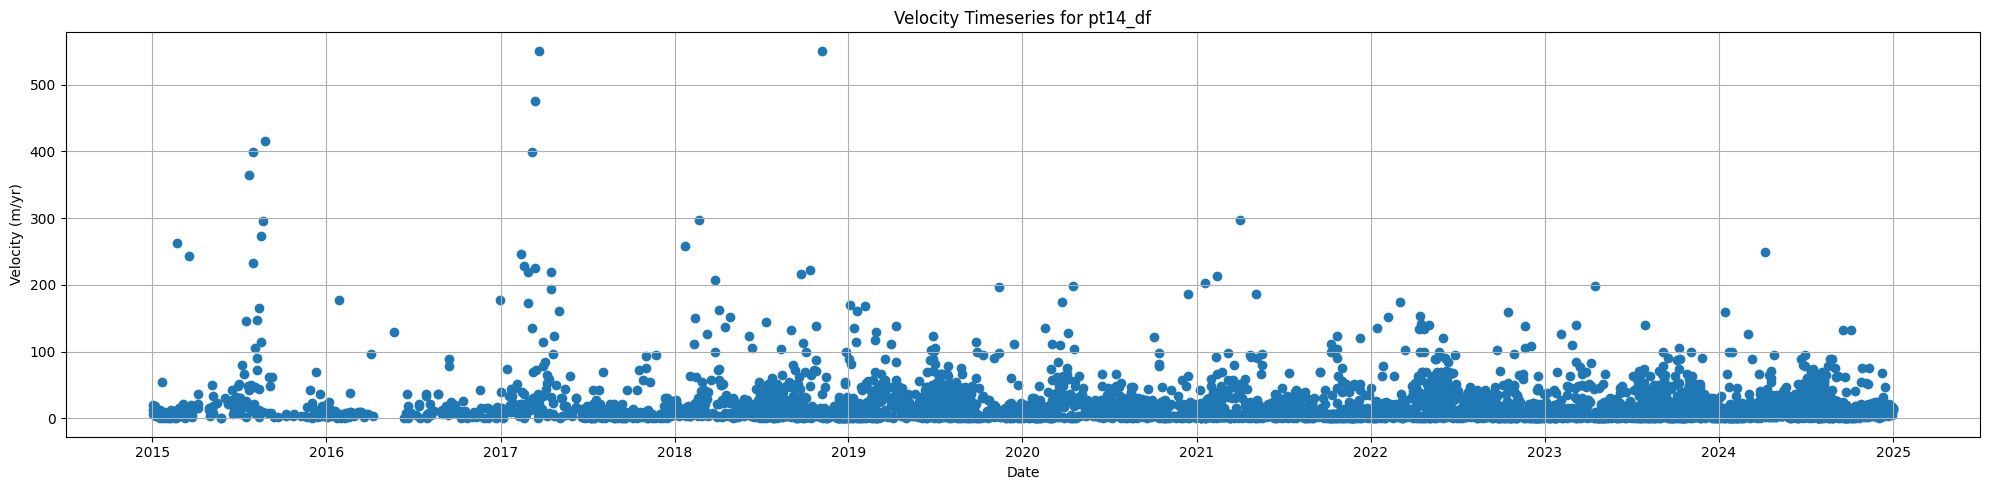

In [10]:
#plot to check
#locate point columns
for key, df in point_dataframes.items():
    plt.figure(figsize=(20, 5))
    plt.scatter(df['mid_date'], df['velocity'], marker='o', linestyle='-')
    plt.title(f'Velocity Timeseries for {key}')
    plt.xlabel('Date')
    plt.ylabel('Velocity (m/yr)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## export combined velocity data

In [11]:
#point_dataframes_df = pd.DataFrame(point_dataframes)
#point_dataframes.to_csv(f'{out_path}{out_name}.csv', index=False)

## create time buckets for each month

In [12]:
#create buckets of time for each month
#define start and end dates for the entire period
start_day = start
end_day = end

#make list of dates for each month
month_intervals = pd.date_range(start=start_day, end=end_day, freq='MS')

#create a list of dictionaries to represent each bucket's start and end dates
month_intervals_list = []
for i in range(len(month_intervals) - 1):
    bucket_start = month_intervals[i].date()
    bucket_end = month_intervals[i + 1].date()
    month_intervals_list.append({'start_date': bucket_start, 'end_date': bucket_end})

#create df from the list of dictionaries
month_buckets = pd.DataFrame(month_intervals_list)

print(month_intervals_list)

[{'start_date': datetime.date(2015, 1, 1), 'end_date': datetime.date(2015, 2, 1)}, {'start_date': datetime.date(2015, 2, 1), 'end_date': datetime.date(2015, 3, 1)}, {'start_date': datetime.date(2015, 3, 1), 'end_date': datetime.date(2015, 4, 1)}, {'start_date': datetime.date(2015, 4, 1), 'end_date': datetime.date(2015, 5, 1)}, {'start_date': datetime.date(2015, 5, 1), 'end_date': datetime.date(2015, 6, 1)}, {'start_date': datetime.date(2015, 6, 1), 'end_date': datetime.date(2015, 7, 1)}, {'start_date': datetime.date(2015, 7, 1), 'end_date': datetime.date(2015, 8, 1)}, {'start_date': datetime.date(2015, 8, 1), 'end_date': datetime.date(2015, 9, 1)}, {'start_date': datetime.date(2015, 9, 1), 'end_date': datetime.date(2015, 10, 1)}, {'start_date': datetime.date(2015, 10, 1), 'end_date': datetime.date(2015, 11, 1)}, {'start_date': datetime.date(2015, 11, 1), 'end_date': datetime.date(2015, 12, 1)}, {'start_date': datetime.date(2015, 12, 1), 'end_date': datetime.date(2016, 1, 1)}, {'start_d

In [13]:
#organize velocity into month buckets
filtered_velocity_data = {}
for bucket_index, bucket in month_buckets.iterrows(): #iterate through rows of df with month buckets
    bucket_start = pd.to_datetime(bucket['start_date']) #change start and end dates to datetime format
    bucket_end = pd.to_datetime(bucket['end_date'])
    filtered_velocity_data[bucket_index] = {} #place to store buckets with velocity data
    for point_name, velocity_df in point_dataframes.items(): #filter so that velocity and time data is organized with buckets
        filtered_df = velocity_df.loc[(velocity_df['mid_date'] >= bucket_start) & (velocity_df['mid_date'] <= bucket_end)].copy()
        filtered_velocity_data[bucket_index][point_name] = filtered_df

print("Filtered velocity data for each bucket and point:")
print(filtered_velocity_data.keys())
print(filtered_velocity_data[0].keys())

Filtered velocity data for each bucket and point:
dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119])
dict_keys(['pt1_df', 'pt2_df', 'pt3_df', 'pt4_df', 'pt5_df', 'pt6_df', 'pt7_df', 'pt8_df', 'pt9_df', 'pt10_df', 'pt11_df', 'pt12_df', 'pt13_df', 'pt14_df'])


## weight and average velocities for each month

In [14]:
weighted_avg_point_bucket = {}

for bucket_index, bucket in month_buckets.iterrows():
    bucket_start = pd.to_datetime(bucket['start_date'])
    bucket_end = pd.to_datetime(bucket['end_date'])
    weighted_avg_point_bucket[bucket_index] = {}
    for i in range(len(points_list)):
        point_name = f'pt{i+1}_df' #use same naming
        itslive_df = velocity_dataframes.get(f'pt{i+1}')
        cautorift_df = cautorift.get(f'pt{i+1}')

        total_weighted_velocity = 0
        total_days = 0

        # Process ITS_LIVE data for the current bucket
        if itslive_df is not None and not itslive_df.empty:
            itslive_bucket_data = itslive_df.loc[(itslive_df['mid_date'] >= bucket_start) & (itslive_df['mid_date'] <= bucket_end)].copy()
            if not itslive_bucket_data.empty:
                overlap_start = itslive_bucket_data['start_date'].clip(lower=bucket_start)
                overlap_end = itslive_bucket_data['end_date'].clip(upper=bucket_end)
                overlap_days = (overlap_end - overlap_start).dt.days + 1
                overlap_days = overlap_days.clip(lower=0)

                valid_itslive_data = itslive_bucket_data.dropna(subset=['velocity (m/yr)']).copy()
                valid_itslive_data['overlap_days'] = overlap_days[valid_itslive_data.index]
                valid_itslive_data = valid_itslive_data[valid_itslive_data['overlap_days'] > 0]

                if not valid_itslive_data.empty:
                    total_weighted_velocity += (valid_itslive_data['velocity (m/yr)'] * valid_itslive_data['overlap_days']).sum()
                    total_days += valid_itslive_data['overlap_days'].sum()

        # Process Cautorift data for the current bucket
        if cautorift_df is not None and not cautorift_df.empty:
            cautorift_bucket_data = cautorift_df.loc[(cautorift_df['mid_date'] >= bucket_start) & (cautorift_df['mid_date'] <= bucket_end)].copy()
            if not cautorift_bucket_data.empty:
                overlap_start = cautorift_bucket_data['start_date'].clip(lower=bucket_start)
                overlap_end = cautorift_bucket_data['end_date'].clip(upper=bucket_end)
                overlap_days = (overlap_end - overlap_start).dt.days + 1
                overlap_days = overlap_days.clip(lower=0)

                valid_cautorift_data = cautorift_bucket_data.dropna(subset=['velocity']).copy()
                valid_cautorift_data['overlap_days'] = overlap_days[valid_cautorift_data.index]
                valid_cautorift_data = valid_cautorift_data[valid_cautorift_data['overlap_days'] > 0]

                if not valid_cautorift_data.empty:
                    total_weighted_velocity += (valid_cautorift_data['velocity'] * valid_cautorift_data['overlap_days']).sum()
                    total_days += valid_cautorift_data['overlap_days'].sum()

        if total_days > 0:
            weighted_avg_point_bucket[bucket_index][point_name] = total_weighted_velocity / total_days
        else:
            weighted_avg_point_bucket[bucket_index][point_name] = np.nan

print("Weighted average velocities per bucket and point:")
# Print the weighted average for point 1 in the first bucket as an example
if 0 in weighted_avg_point_bucket and 'pt1_df' in weighted_avg_point_bucket[0]:
    print(weighted_avg_point_bucket[0]['pt1_df'])
else:
    print("No weighted average data available for point 1 in the first bucket.")

Weighted average velocities per bucket and point:
28.22222222222222


In [15]:
#convert dictionary to df
weighted_avg_df = pd.DataFrame.from_dict(weighted_avg_point_bucket, orient='index')

#add mid_date column using the start date of the month_buckets and adding 14 days
weighted_avg_df['mid_date'] = month_buckets['start_date'] + pd.Timedelta(days=14)

print("DataFrame of weighted average velocities:")
display(weighted_avg_df)

DataFrame of weighted average velocities:


,pt1_df,pt2_df,pt3_df,pt4_df,pt5_df,pt6_df,pt7_df,pt8_df,pt9_df,pt10_df,pt11_df,pt12_df,pt13_df,pt14_df,mid_date
0,28.222222,53.600000,94.411765,83.384615,78.666667,144.857143,89.777778,101.909091,101.533333,136.833333,68.625000,83.666667,NaN,9.653846,2015-01-15
1,50.850000,50.764706,115.727273,70.222222,155.250000,96.600000,69.400000,106.600000,110.636364,125.400000,107.200000,103.000000,NaN,16.560000,2015-02-15
2,51.640000,33.400000,133.666667,84.111111,86.900000,68.142857,96.666667,112.400000,116.500000,102.533333,127.625000,99.000000,190.00,21.250000,2015-03-15
3,22.909091,52.727273,104.125000,87.800000,129.000000,144.666667,107.000000,61.200000,81.400000,94.857143,77.400000,38.400000,67.00,20.200000,2015-04-15
4,25.764706,36.083333,125.000000,124.250000,NaN,97.000000,58.500000,68.000000,81.444444,68.555556,38.333333,35.000000,NaN,17.125000,2015-05-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,11.731092,9.627119,39.857143,75.285714,51.571429,78.000000,57.833333,36.921053,81.020833,62.839286,51.117647,47.125000,23.00,17.826667,2024-08-15
116,15.910891,15.906250,47.485714,63.045455,61.500000,87.333333,56.125000,49.800000,69.106383,66.034483,53.965517,39.107143,NaN,14.900000,2024-09-15
117,26.654545,28.037037,55.076923,89.823529,62.500000,215.000000,104.666667,41.352941,76.833333,63.852941,46.772727,39.363636,175.00,14.750000,2024-10-15
118,21.277778,45.890909,64.469388,77.513514,71.142857,68.444444,54.571429,79.050000,90.666667,58.406250,40.750000,47.500000,130.75,15.857143,2024-11-15


## plot weighted average monthly velocities at each point

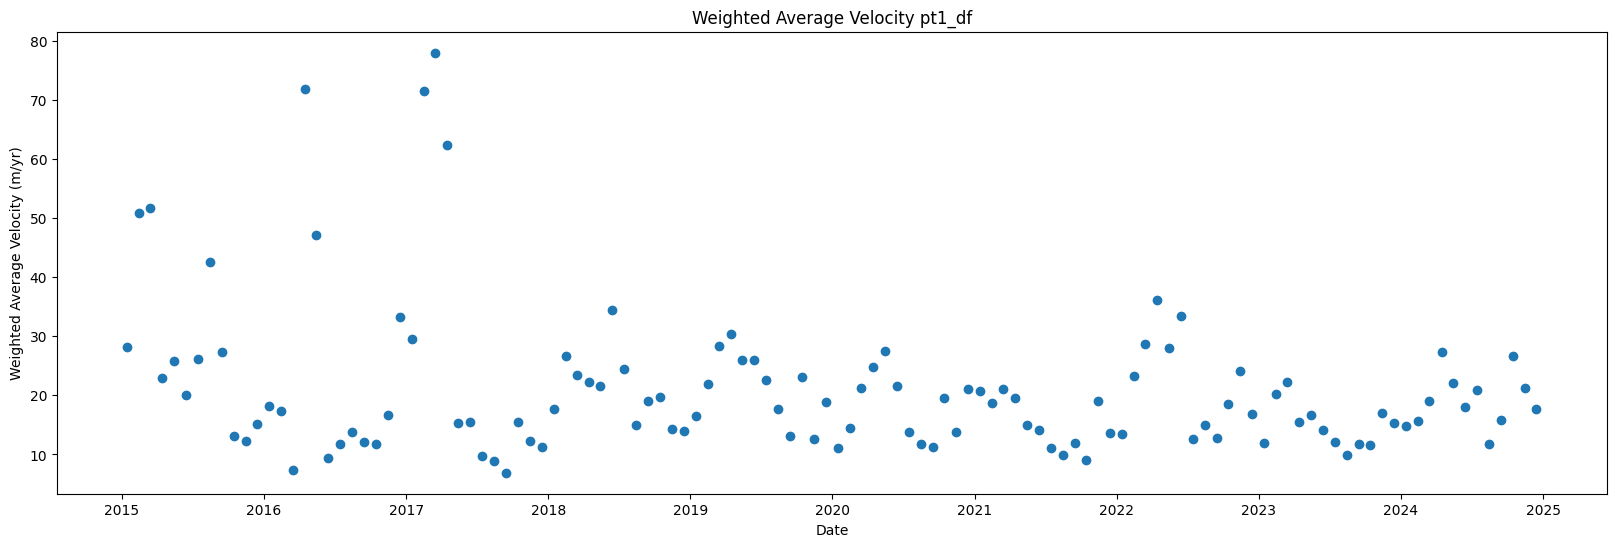

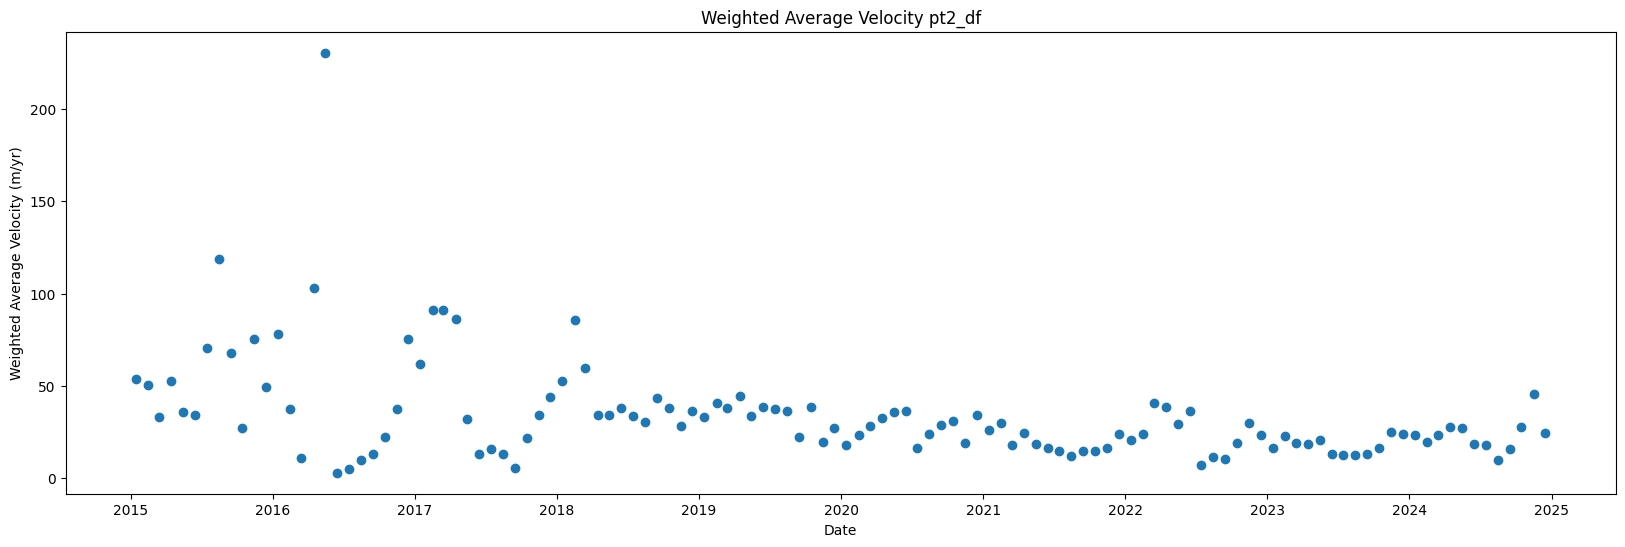

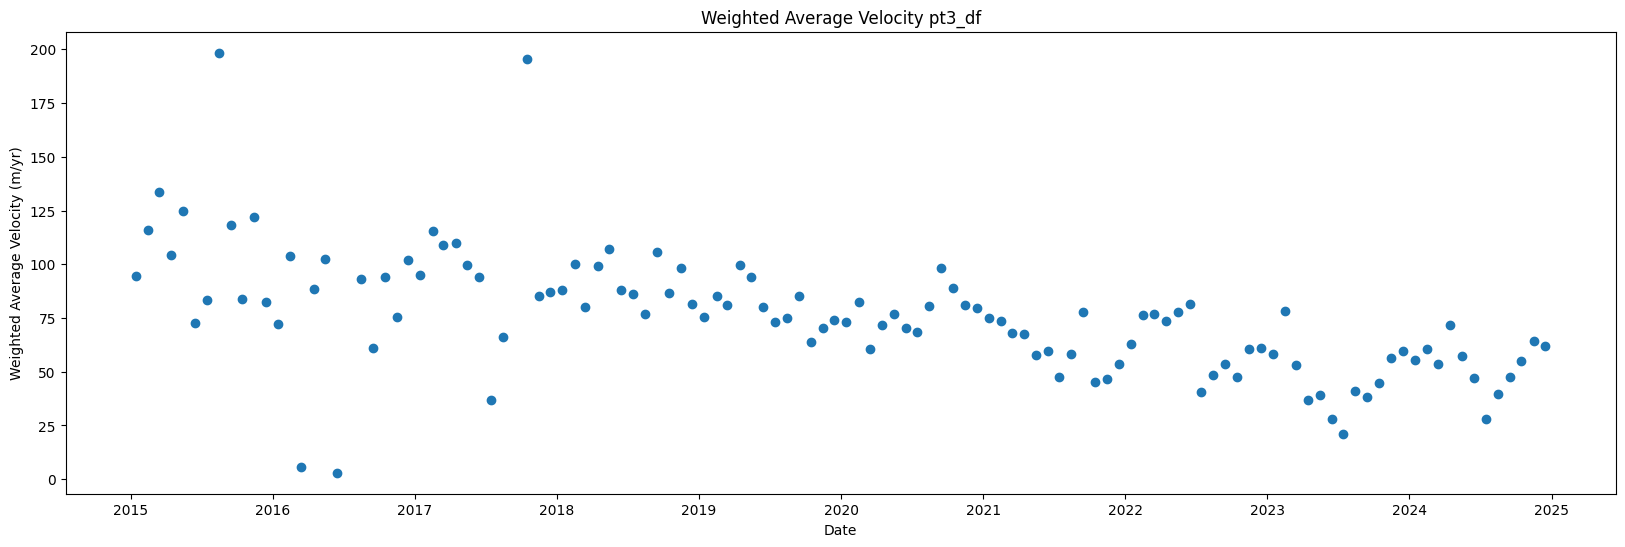

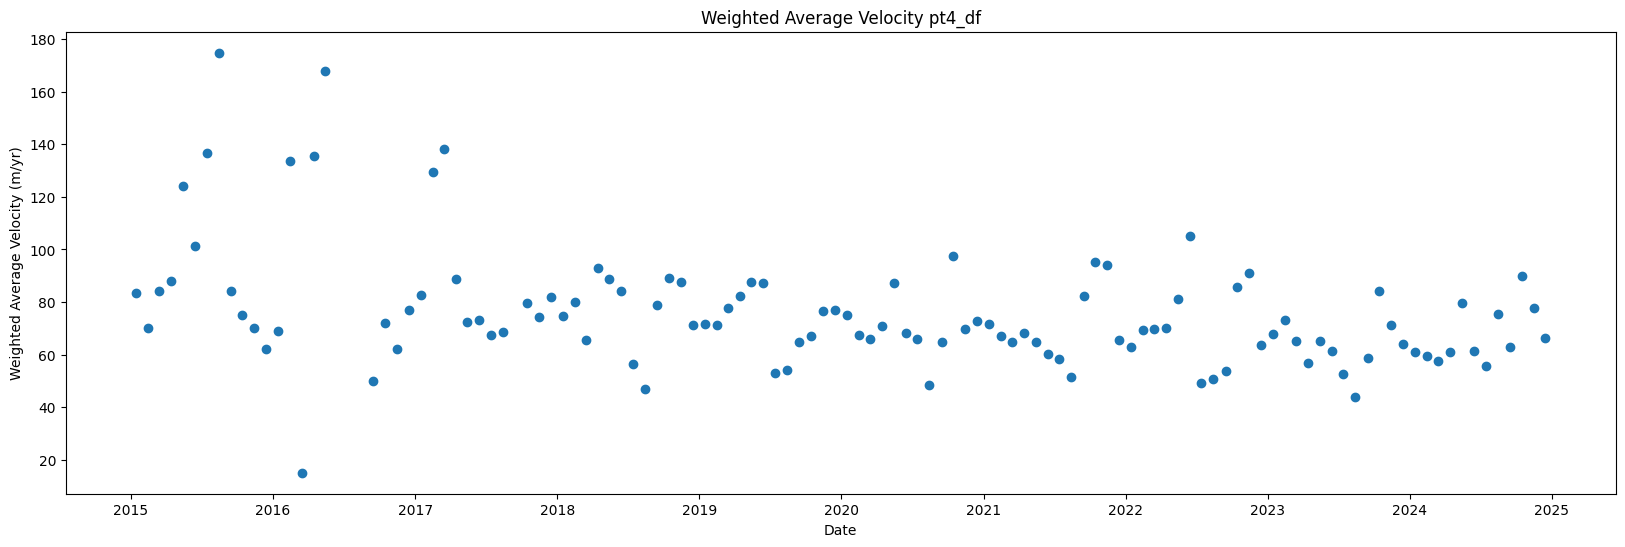

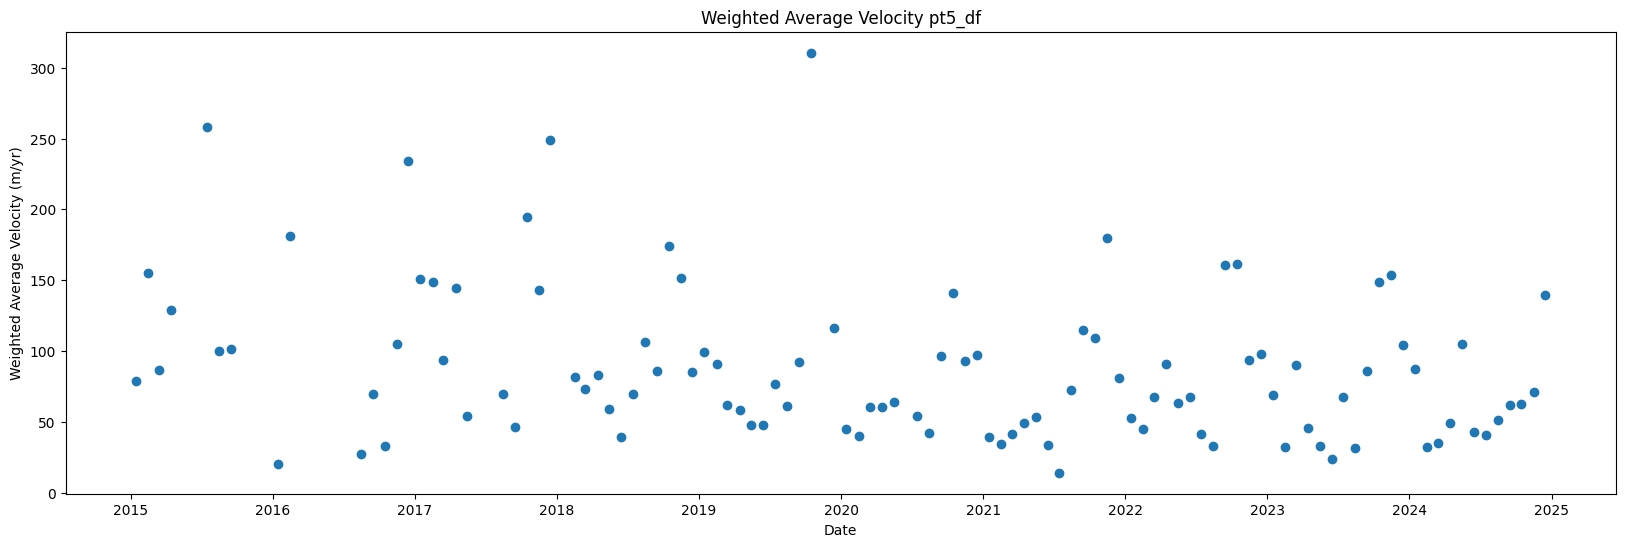

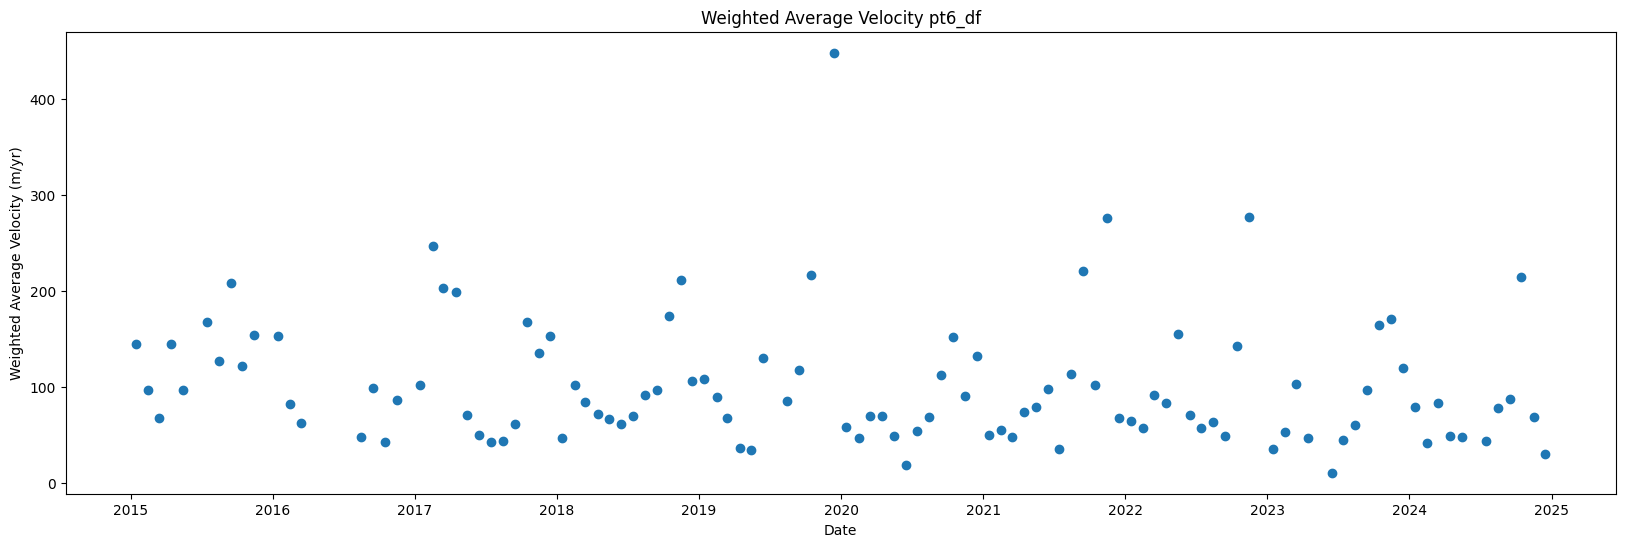

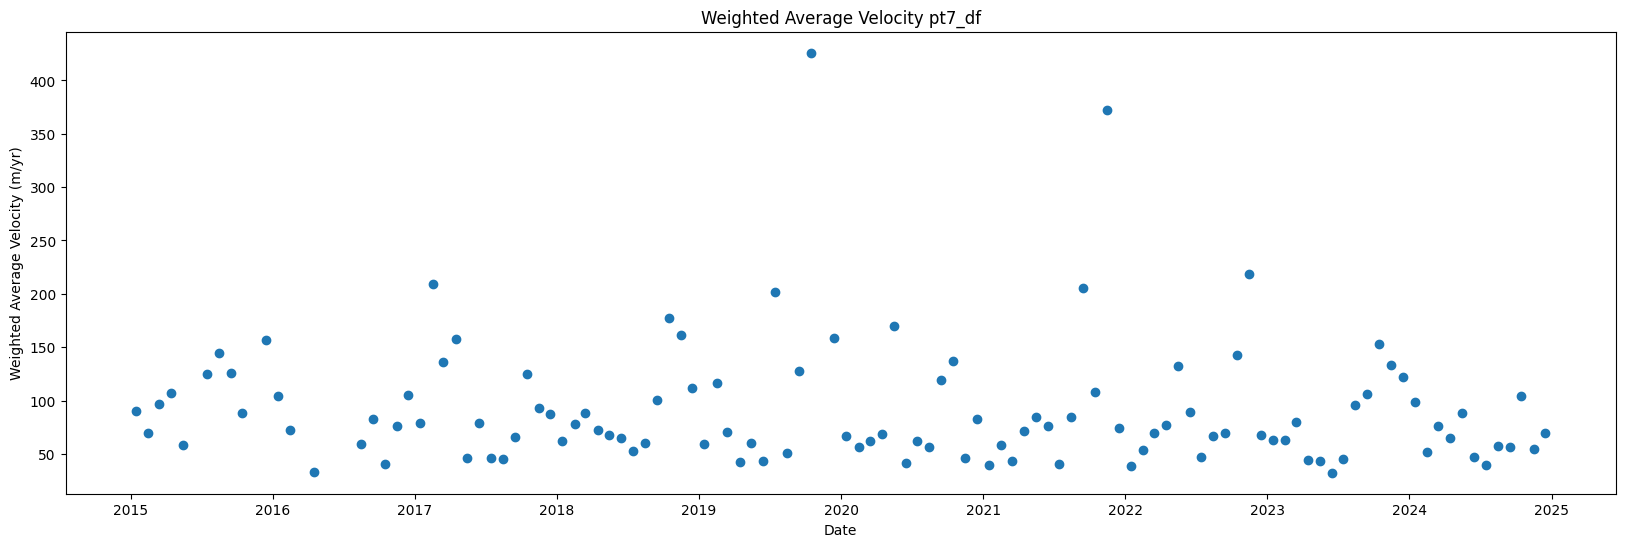

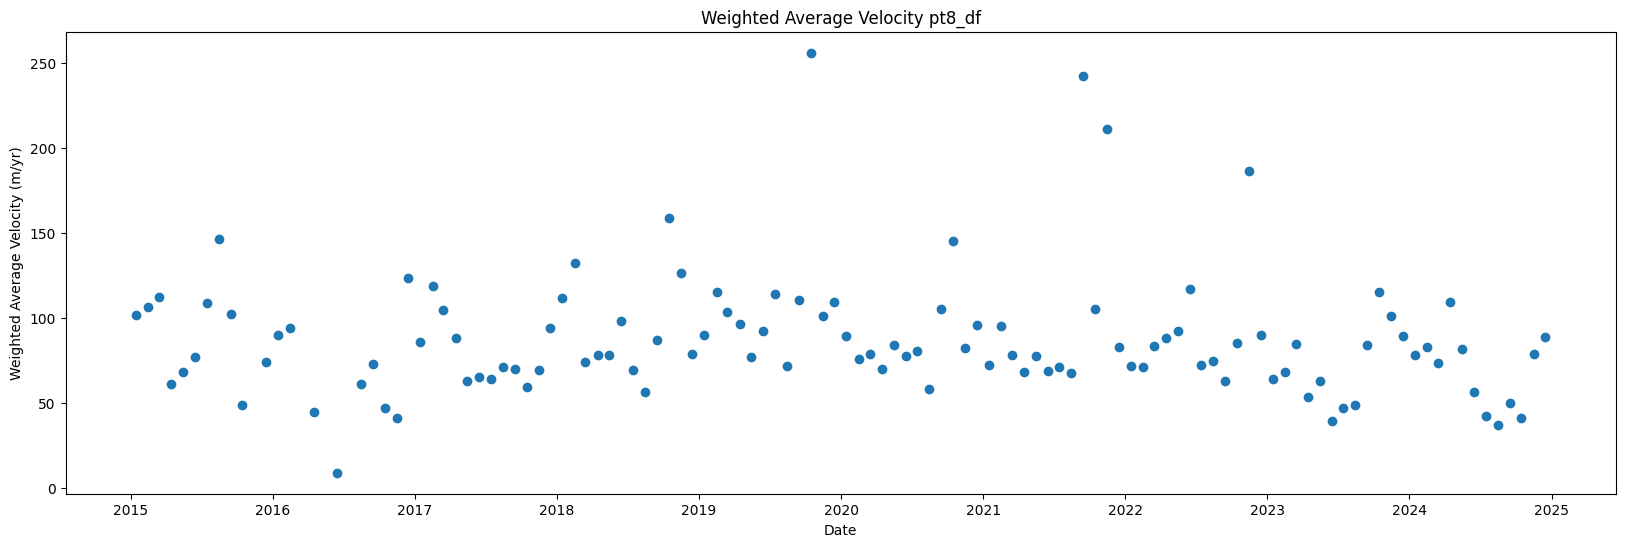

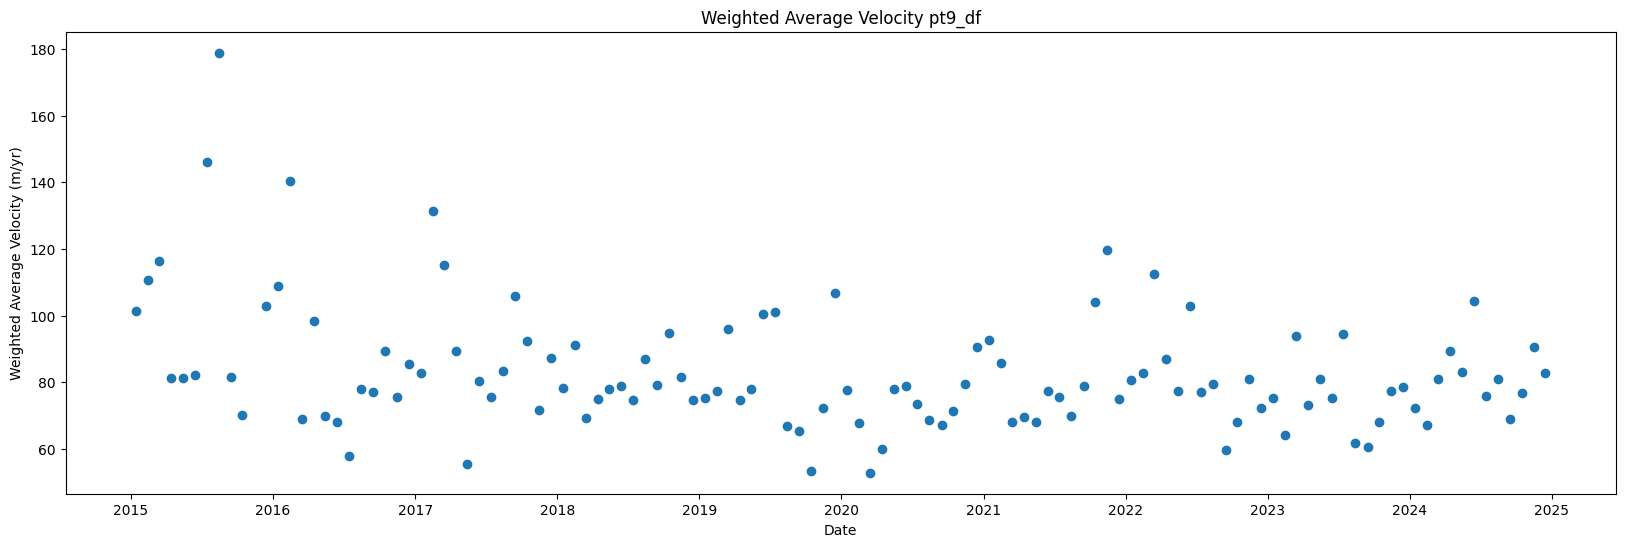

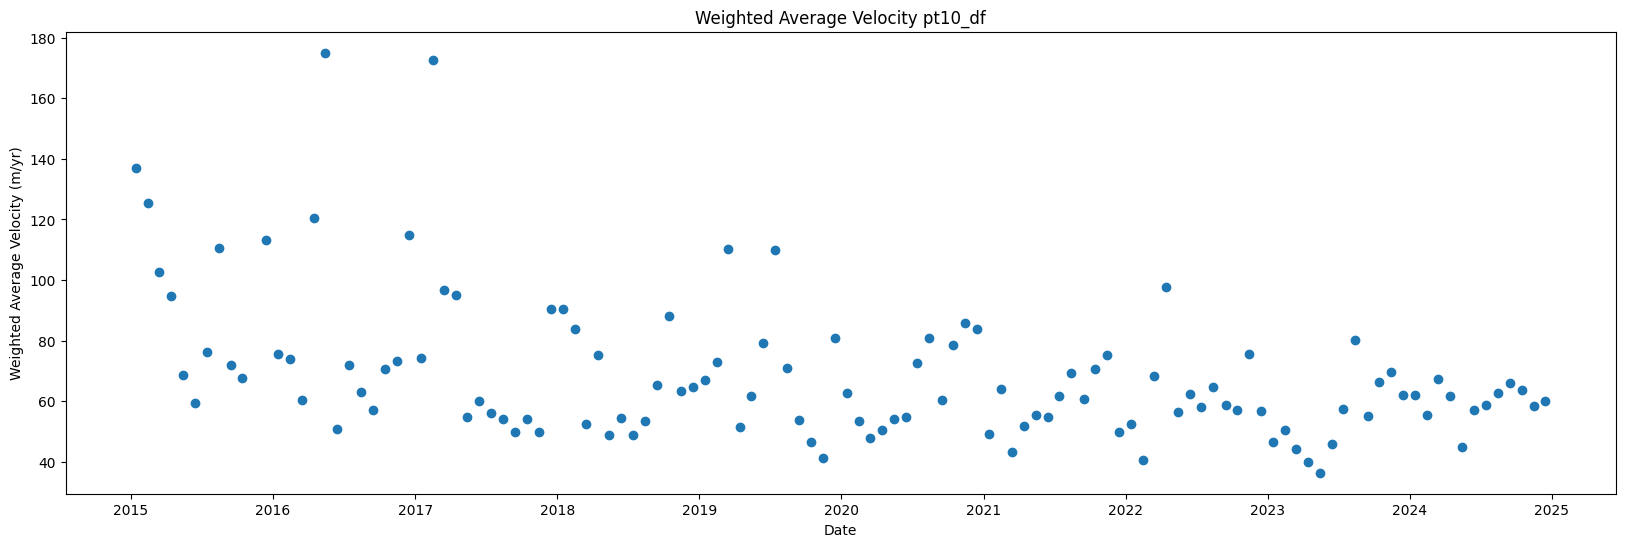

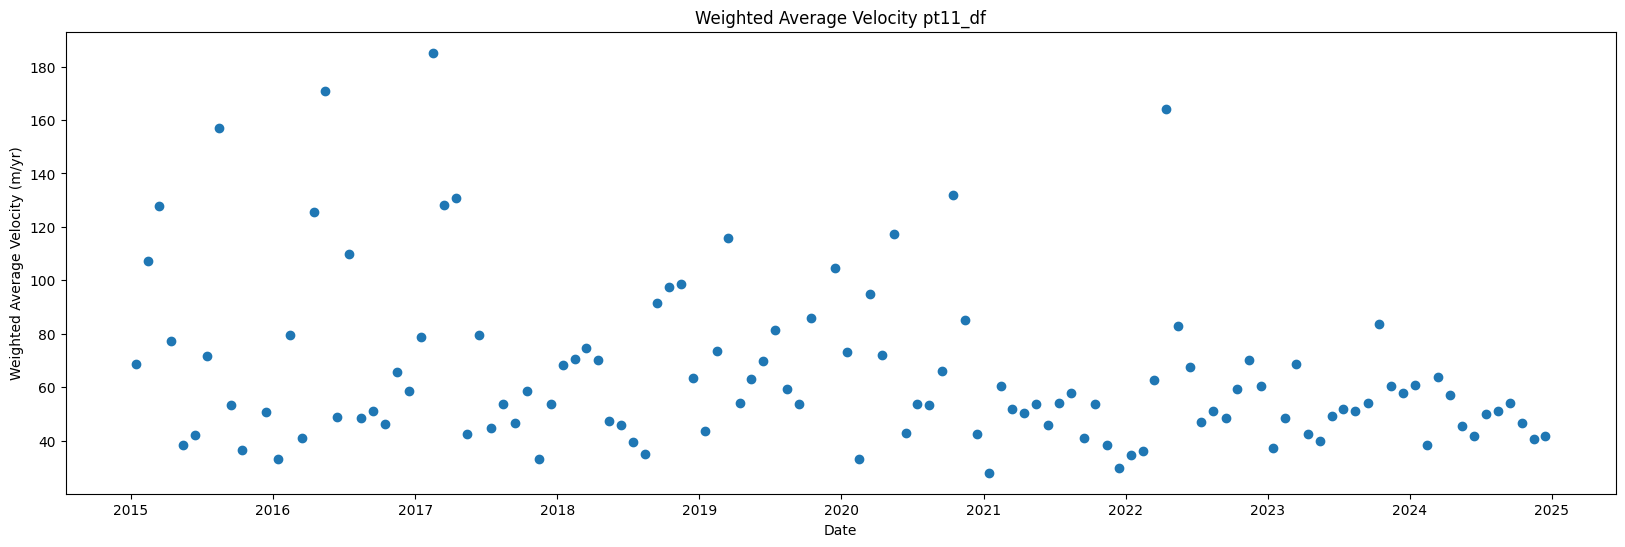

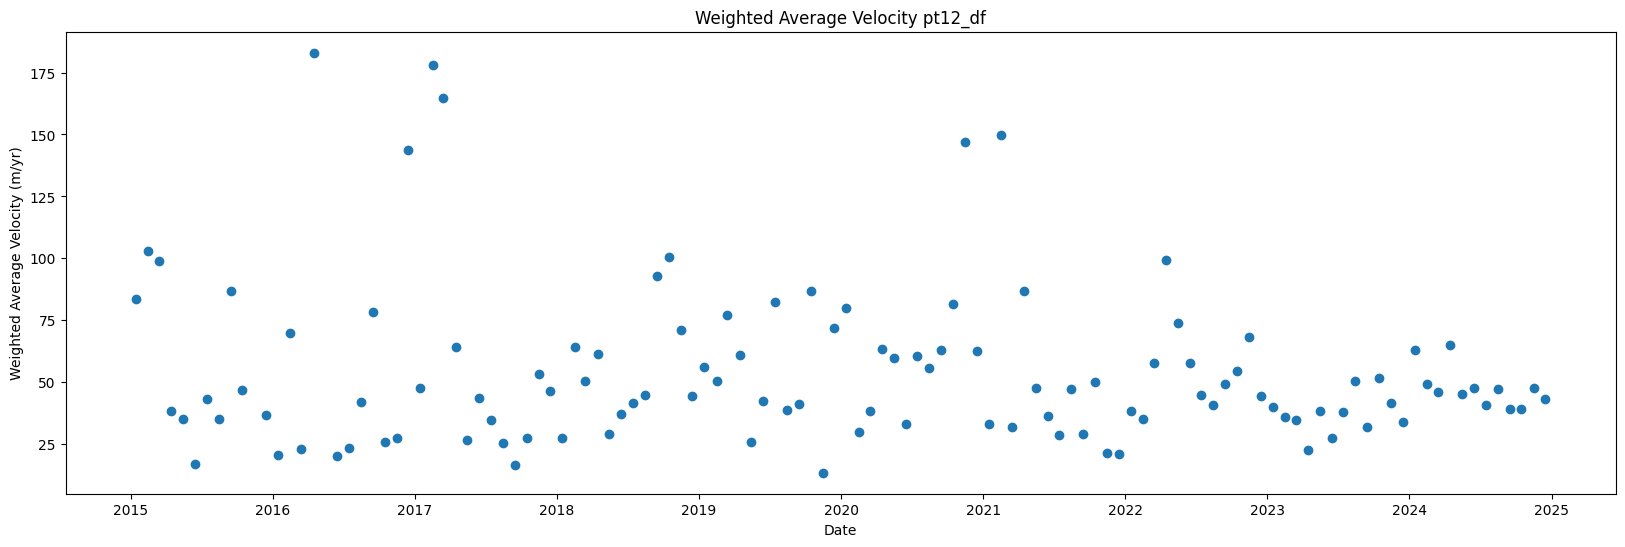

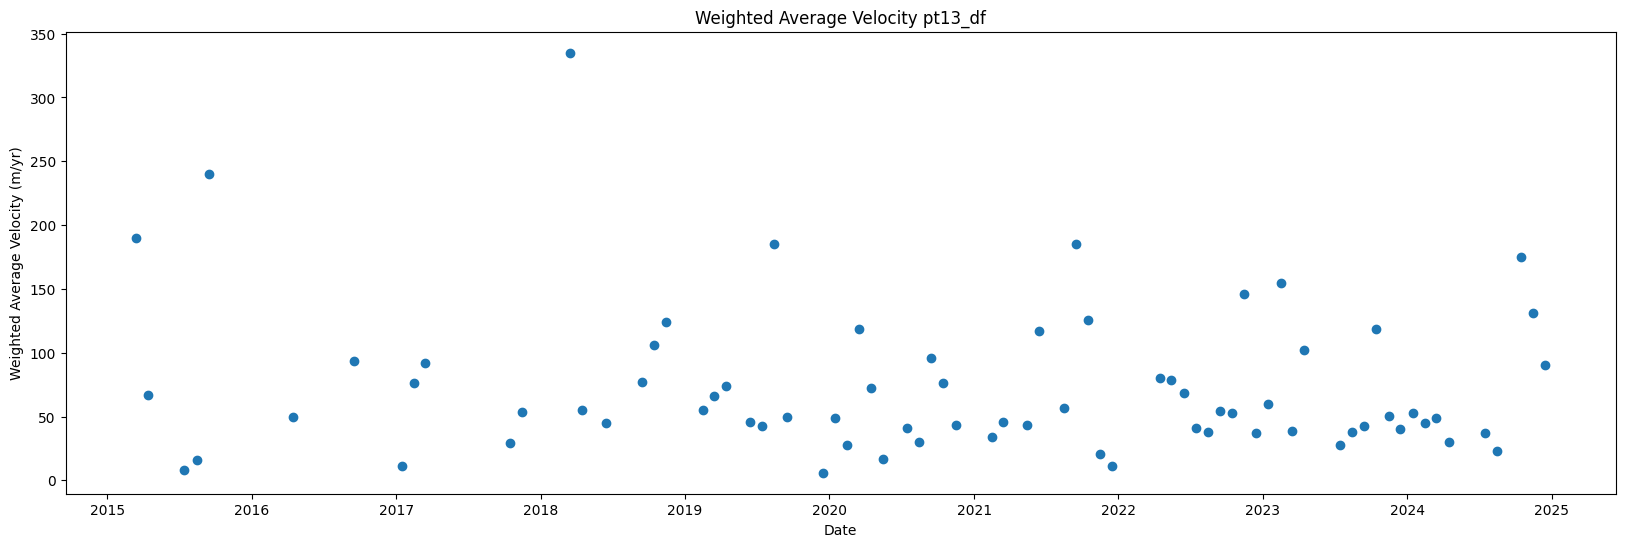

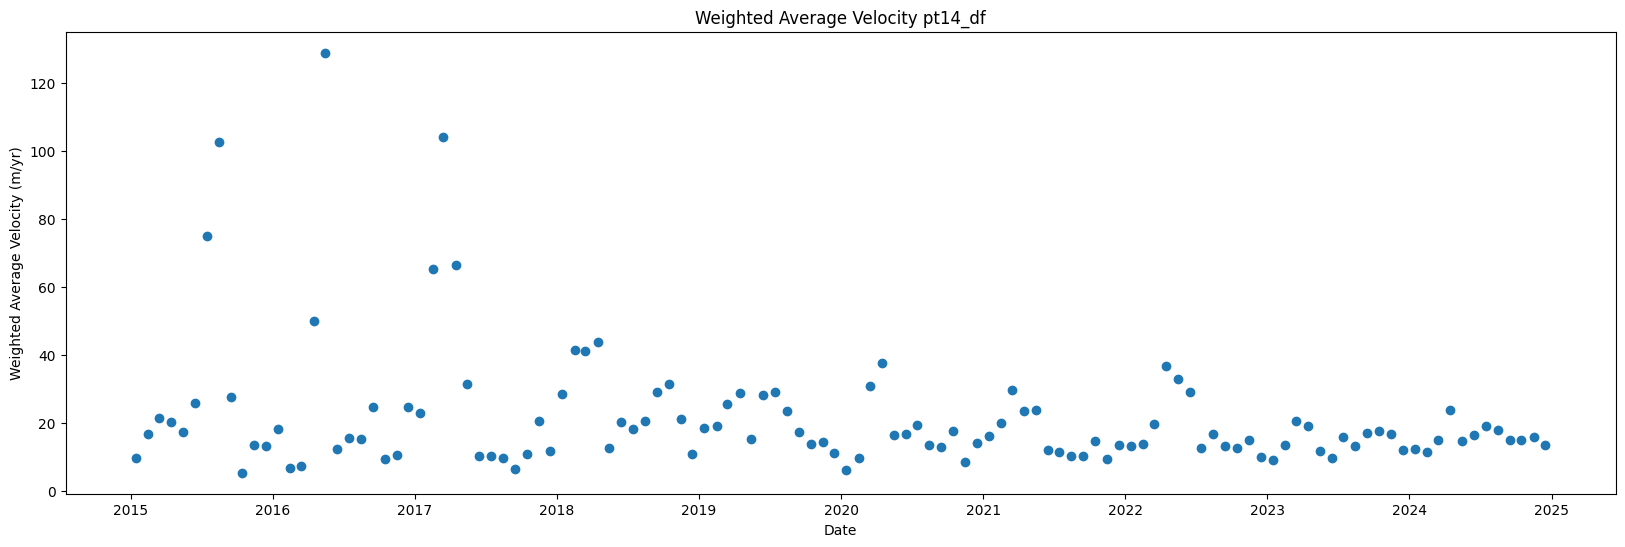

In [16]:
for column in weighted_avg_df.columns:
    if column != 'mid_date':
        plt.figure(figsize=(20, 6))
        plt.scatter(weighted_avg_df['mid_date'], weighted_avg_df[column])
        plt.title(f'Weighted Average Velocity {column}')
        plt.xlabel('Date')
        plt.ylabel('Weighted Average Velocity (m/yr)')
        #plt.ylim(-5, 500)
        plt.show()

## export results

In [17]:
weighted_avg_df.to_csv(f'{out_path}{out_name}.csv', index=False)

In [18]:
#weight velocities based on number of days date_dt is within each bucket
# weighted_avg_velocities = {} #store results in a dictionary
# for bucket_index, bucket in month_buckets.iterrows(): #iterate through each row in the df of time buckets
#     bucket_start = pd.to_datetime(bucket['start_date']) #start date of current bucket (dt1)
#     bucket_end = pd.to_datetime(bucket['end_date']) #end date of current bucket (dt2)
#     total_weighted_velocity = 0 # start with zeros to account for places with no data
#     total_days = 0
#     for i in point_dataframes.keys():
#         df = point_dataframes.get(f'{i}')

#         #process data
#         if df is not None and not df.empty:
#             #filter data to current bucket
#             bucket_data = df.loc[(df['mid_date'] >= bucket_start) & (df['mid_date'] <= bucket_end)].copy()

#             if not bucket_data.empty:
#                 #calculate number of days the date_dt overlaps with the bucket
#                 overlap_start = bucket_data['start_date'].clip(lower=bucket_start)
#                 overlap_end = bucket_data['end_date'].clip(upper=bucket_end)
#                 overlap_days = (overlap_end - overlap_start).dt.days + 1
#                 overlap_days = overlap_days.clip(lower=0)

#                 #only consider rows with non-NaN velocity and positive overlap days
#                 valid_data = bucket_data.dropna(subset=['velocity (m/yr)']).copy()
#                 valid_data['overlap_days'] = overlap_days[valid_data.index]
#                 valid_data = valid_data[valid_data['overlap_days'] > 0]

#                 if not valid_data.empty:
#                     total_weighted_velocity += (valid_data['velocity (m/yr)'] * valid_data['overlap_days']).sum()
#                     total_days += valid_data['overlap_days'].sum()


#     if total_days > 0:
#         weighted_avg_velocities[bucket_index] = total_weighted_velocity / total_days
#     else:
#         weighted_avg_velocities[bucket_index] = np.nan

# #convert results to a pandas Series for easier handling
# weighted_avg_series = pd.Series(weighted_avg_velocities)

# print("Weighted average velocities per bucket:")
# print(weighted_avg_series)